# 05 — Convergence analysis

Quantitative characterisation: rate versus rho, versus topology, versus problem size. Everything here is a measurement with error bars, not a single run.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from distributed_mpc_admm import plotting

plotting.apply_style("notebook")
rng = np.random.default_rng(0)

## Protocol

30 seeds per configuration, random initial conditions from a fixed distribution, fixed rho (adaptation off), `eps_abs = eps_rel = 1e-6`. State it here and do not deviate -- half the value of this notebook is that the numbers are comparable.

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import distributed_mpc_admm
from distributed_mpc_admm import (
    ADMMOptions,
    ConsensusADMM,
    DistributedMPC,
    MPCOptions,
    plotting,
)
from distributed_mpc_admm.communication_graph import CommunicationGraph
from distributed_mpc_admm.formation_constraints import FormationSpec
from distributed_mpc_admm.per_agent_solver import (
    AgentCostWeights,
    AgentLimits,
    CvxpyAgentSolver,
    DoubleIntegrator,
)

# --- protocol (do not deviate) -----------------------------------------------
# 30 seeds per configuration, fixed rho (adaptation off), eps_abs = eps_rel = TOL.
# Everything below is a measurement with error bars, never a single run. On CI the
# seed count is shrunk but the protocol is otherwise identical.
SEEDS = 3 if os.environ.get("NB_CI") == "1" else 30
TOL = 1e-6
MAX_ITER = 3000

repo_root = Path(distributed_mpc_admm.__file__).resolve().parent.parent.parent

_model = DoubleIntegrator(dt=0.1, dim=2)
_limits = AgentLimits()
_weights = AgentCostWeights()


def _solvers(
    graph: CommunicationGraph, horizon: int, offsets: dict | None = None
) -> dict[int, CvxpyAgentSolver]:
    """One solver per agent, rendezvous (zero) offsets, matching the closed neighborhood."""
    return {
        i: CvxpyAgentSolver(
            agent_id=i,
            horizon=horizon,
            model=_model,
            limits=_limits,
            weights=_weights,
            neighborhood=tuple(graph.closed_neighborhood(i)),
            offsets=dict(offsets[i]) if offsets and offsets.get(i) else None,
        )
        for i in range(graph.n_agents)
    }


def run_trial(
    graph: CommunicationGraph,
    *,
    seed: int,
    horizon: int = 10,
    rho: float = 1.0,
    adaptive_rho: bool = False,
    max_iterations: int = MAX_ITER,
):
    """One open-loop consensus-ADMM solve from a seeded random initial state.

    Random initial conditions come from a fixed distribution (unit-Gaussian positions,
    half-scale Gaussian velocities) so every number in this notebook is reproducible.
    Returns the :class:`ADMMResult`.
    """
    offsets = {
        i: {j: np.zeros(_model.dim) for j in graph.neighbors(i)}
        for i in range(graph.n_agents)
    }
    solvers = _solvers(graph, horizon, offsets=offsets)
    rng = np.random.default_rng(seed)
    x0 = rng.normal(size=(graph.n_agents, _model.n_states))
    x0[:, _model.dim :] *= 0.5
    references = {i: np.zeros((horizon, _model.dim)) for i in range(graph.n_agents)}
    options = ADMMOptions(
        rho=rho,
        max_iterations=max_iterations,
        eps_abs=TOL,
        eps_rel=TOL,
        adaptive_rho=adaptive_rho,
    )
    admm = ConsensusADMM(graph, solvers, horizon, _model.dim, options)
    return admm.solve(x0=x0, references=references, offsets=offsets)


## Empirical linear rate

Fit `log(r_k)` versus `k` and compare against the theoretical linear rate.

empirical linear rate = -0.1991  (log-residual slope)
lambda_2 = 2.0000; theoretical rate scales with spectral gap, not rho
iterations = 62, converged = True


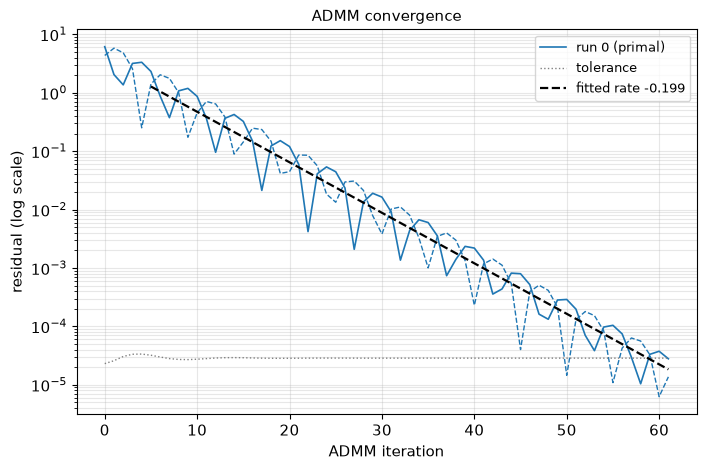

In [3]:
graph = CommunicationGraph.cycle(4)
trial = run_trial(graph, seed=0)
history = trial.history

# Least-squares slope of log(primal_residual) vs iteration, skipping the transient
# head of the run. This is the measured linear rate; the proof in
# docs/derivations/convergence_proof.tex bounds it in terms of lambda_2.
rate = history.empirical_rate(skip_initial=5)
lam2 = graph.algebraic_connectivity()
print(f"empirical linear rate = {rate:.4f}  (log-residual slope)")
print(f"lambda_2 = {lam2:.4f}; theoretical rate scales with spectral gap, not rho")
print(f"iterations = {trial.iterations}, converged = {trial.converged}")

ax = plotting.plot_convergence(history, show_tolerances=True)
residual = np.asarray(history.primal_residual, dtype=float)
k = np.arange(len(residual), dtype=float)
mask = (k >= 5) & (residual > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(k[mask], np.log(residual[mask]), 1)
    ax.semilogy(
        k[mask],
        np.exp(intercept + slope * k[mask]),
        "k--",
        linewidth=1.6,
        label=f"fitted rate {slope:.3f}",
    )
    ax.legend(loc="best", fontsize="small")
plt.show()


## Rho sweep

The U-curve. Locate the empirical optimum and compare it to the rho suggested by the objective/penalty scaling heuristic.

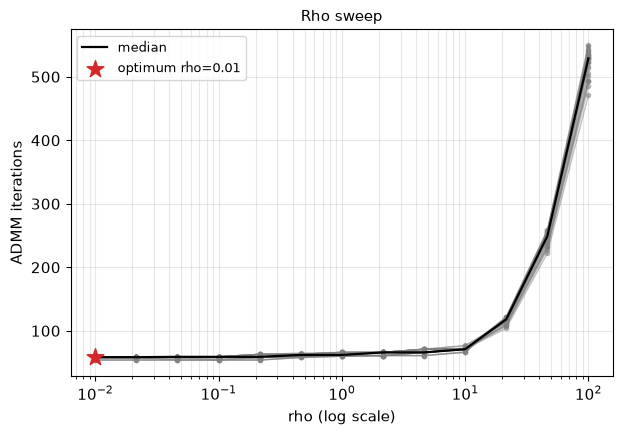

empirical optimum rho = 0.01 (58.5 iterations)
scaling-heuristic rho = 4.472
median iterations at rho=0.01: 58.5  | rho=100: 529.0


In [4]:
rho_values = np.logspace(-2, 2, 13) if not os.environ.get("NB_CI") == "1" else np.logspace(-2, 2, 7)
graph = CommunicationGraph.cycle(4)

rho_iters = np.full((len(rho_values), SEEDS), np.nan)
for i, rho in enumerate(rho_values):
    for s in range(SEEDS):
        rho_iters[i, s] = run_trial(graph, seed=s, rho=rho).iterations

plotting.plot_rho_sweep(rho_values, rho_iters)
plt.show()

rho_median = np.median(rho_iters, axis=1)
best = int(np.argmin(rho_median))
best_rho = float(rho_values[best])

# Order-of-magnitude scaling heuristic: rho should sit near the objective curvature,
# which for w_formation = 10 is sqrt(2*w_formation) ~ 4.5. Report both, not a claim.
heuristic_rho = float(np.sqrt(2.0 * _weights.w_formation))
print(f"empirical optimum rho = {best_rho:.4g} ({rho_median[best]:.1f} iterations)")
print(f"scaling-heuristic rho = {heuristic_rho:.4g}")
print(f"median iterations at rho={rho_values[0]:.3g}: {rho_median[0]:.1f}  "
      f"| rho={rho_values[-1]:.3g}: {rho_median[-1]:.1f}")


## Topology sweep

Iterations versus algebraic connectivity across complete/star/cycle/path/random.

fitted power-law exponent beta = 0.282  (consensus bound predicts ~ -0.5)


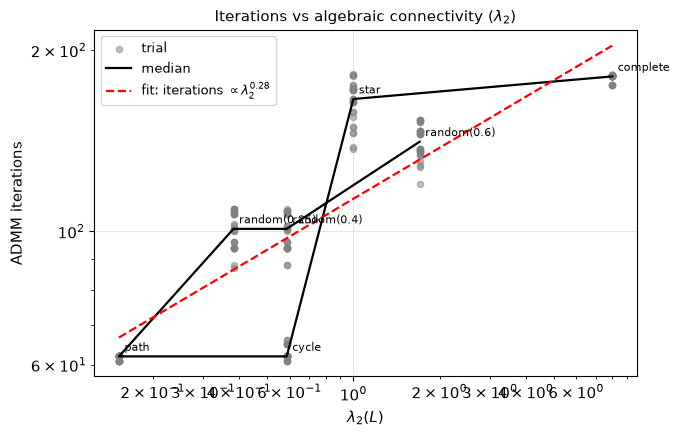

complete      : lambda_2=8.000, median iterations=181.0
star          : lambda_2=1.000, median iterations=166.0
cycle         : lambda_2=0.586, median iterations=62.0
path          : lambda_2=0.152, median iterations=62.0
random(0.25)  : lambda_2=0.382, median iterations=101.0
random(0.4)   : lambda_2=0.586, median iterations=101.0
random(0.6)   : lambda_2=1.704, median iterations=141.0


In [5]:
N = 8
# Four named families plus a few random connected graphs to populate the lambda_2 axis.
topologies: list[CommunicationGraph] = [
    CommunicationGraph.complete(N),
    CommunicationGraph.star(N),
    CommunicationGraph.cycle(N),
    CommunicationGraph.path(N),
    CommunicationGraph.random_connected(N, edge_prob=0.25, rng=0),
    CommunicationGraph.random_connected(N, edge_prob=0.4, rng=1),
    CommunicationGraph.random_connected(N, edge_prob=0.6, rng=2),
]
topo_names = ["complete", "star", "cycle", "path", "random(0.25)", "random(0.4)", "random(0.6)"]

lam2 = np.array([g.algebraic_connectivity() for g in topologies])
topo_iters = np.full((len(topologies), SEEDS), np.nan)
for i, g in enumerate(topologies):
    for s in range(SEEDS):
        topo_iters[i, s] = run_trial(g, seed=s).iterations

topo_median = np.median(topo_iters, axis=1)

# Power law: iterations ~ C * lambda_2^beta. The consensus bound suggests beta ~ -1/2
# (iterations ~ 1/sqrt(lambda_2)); measure the realised exponent.
mask = lam2 > 0
beta, log_c = np.polyfit(np.log(lam2[mask]), np.log(topo_median[mask]), 1)
print(f"fitted power-law exponent beta = {beta:.3f}  (consensus bound predicts ~ -0.5)")

ax = plotting.plot_iterations_to_consensus(lam2, topo_iters, xlabel=r"$\lambda_2(L)$")
ax.set_xscale("log")
ax.set_yscale("log")
xs = np.geomspace(lam2.min(), lam2.max(), 50)
ax.plot(xs, np.exp(log_c) * xs**beta, "r--", linewidth=1.6,
        label=rf"fit: iterations $\propto \lambda_2^{{{beta:.2f}}}$")
ax.set_title(r"Iterations vs algebraic connectivity ($\lambda_2$)")
ax.legend(loc="best", fontsize="small")
for x, y, name in zip(lam2, topo_median, topo_names, strict=False):
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(4, 4), fontsize="x-small")
plt.show()

for name, x, med in zip(topo_names, lam2, topo_median, strict=False):
    print(f"{name:14s}: lambda_2={x:.3f}, median iterations={med:.1f}")


## Size sweep

N in 2..8 at fixed topology family. Separate iteration count from wall time -- they scale differently and conflating them hides the real story.

iterations ~ N^0.26,  wall time ~ N^1.26


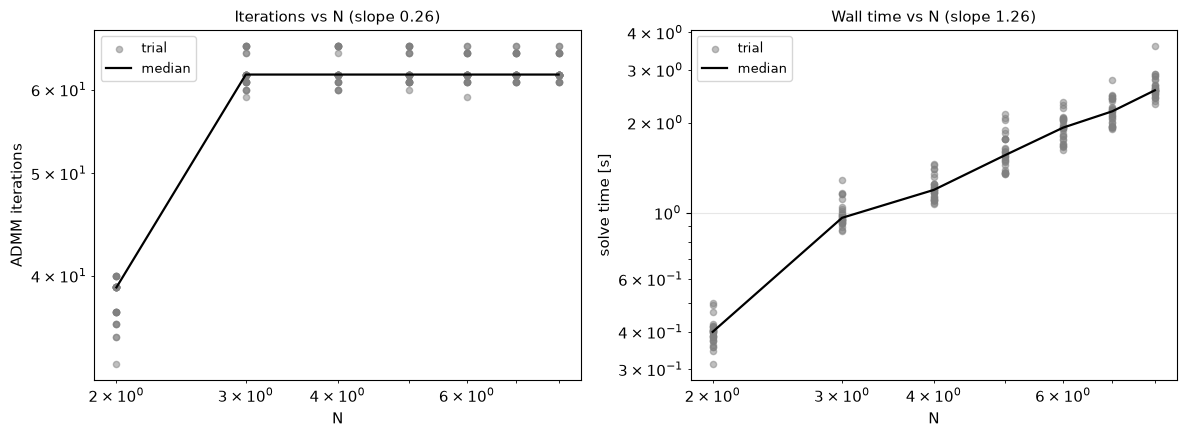

In [6]:
Ns = np.arange(2, 9)
size_iters = np.full((len(Ns), SEEDS), np.nan)
size_times = np.full((len(Ns), SEEDS), np.nan)

for i, n in enumerate(Ns):
    g = CommunicationGraph.cycle(n)
    for s in range(SEEDS):
        r = run_trial(g, seed=s)
        size_iters[i, s] = r.iterations
        size_times[i, s] = r.solve_time

size_median_iters = np.median(size_iters, axis=1)
size_median_times = np.median(size_times, axis=1)
slope_iters = float(np.polyfit(np.log(Ns), np.log(size_median_iters), 1)[0])
slope_times = float(np.polyfit(np.log(Ns), np.log(size_median_times), 1)[0])
print(f"iterations ~ N^{slope_iters:.2f},  wall time ~ N^{slope_times:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
plotting.plot_iterations_to_consensus(Ns, size_iters, ax=ax1, xlabel="N")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_title(f"Iterations vs N (slope {slope_iters:.2f})")

for trial in range(size_times.shape[1]):
    ax2.scatter(Ns, size_times[:, trial], color="grey", alpha=0.5, s=20,
                label="trial" if trial == 0 else None)
ax2.plot(Ns, size_median_times, "k-", linewidth=1.6, label="median")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("N")
ax2.set_ylabel("solve time [s]")
ax2.set_title(f"Wall time vs N (slope {slope_times:.2f})")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best", fontsize="small")
plt.tight_layout()
plt.show()


## Horizon sweep

T in 5..40. Iterations should be nearly flat; per-iteration cost is not.

iterations ~ T^-0.03,  wall time ~ T^0.23


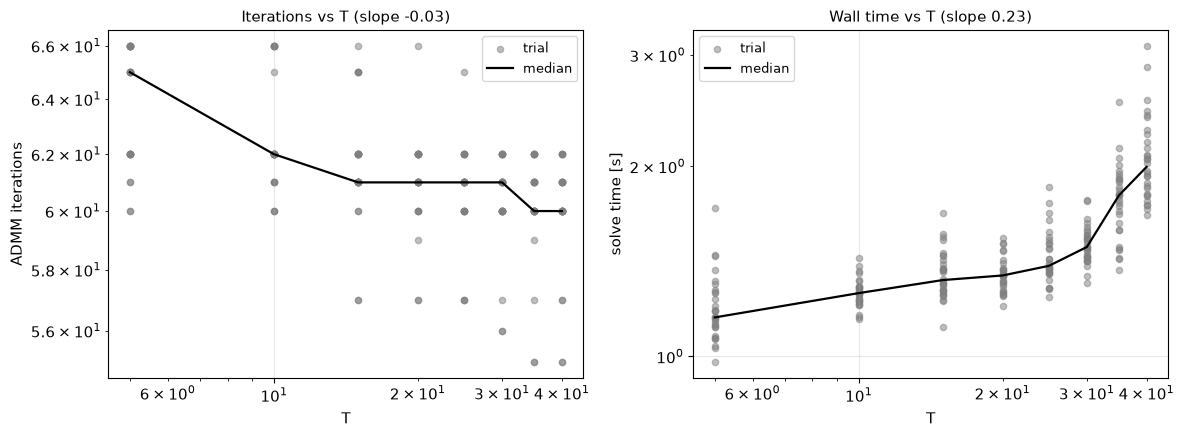

In [7]:
Ts = np.arange(5, 41, 5)
graph = CommunicationGraph.cycle(4)
horizon_iters = np.full((len(Ts), SEEDS), np.nan)
horizon_times = np.full((len(Ts), SEEDS), np.nan)

for i, T in enumerate(Ts):
    for s in range(SEEDS):
        r = run_trial(graph, seed=s, horizon=int(T))
        horizon_iters[i, s] = r.iterations
        horizon_times[i, s] = r.solve_time

horizon_median_iters = np.median(horizon_iters, axis=1)
horizon_median_times = np.median(horizon_times, axis=1)
slope_iters = float(np.polyfit(np.log(Ts), np.log(horizon_median_iters), 1)[0])
slope_times = float(np.polyfit(np.log(Ts), np.log(horizon_median_times), 1)[0])
print(f"iterations ~ T^{slope_iters:.2f},  wall time ~ T^{slope_times:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
plotting.plot_iterations_to_consensus(Ts, horizon_iters, ax=ax1, xlabel="T")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_title(f"Iterations vs T (slope {slope_iters:.2f})")

for trial in range(horizon_times.shape[1]):
    ax2.scatter(Ts, horizon_times[:, trial], color="grey", alpha=0.5, s=20,
                label="trial" if trial == 0 else None)
ax2.plot(Ts, horizon_median_times, "k-", linewidth=1.6, label="median")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("T")
ax2.set_ylabel("solve time [s]")
ax2.set_title(f"Wall time vs T (slope {slope_times:.2f})")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best", fontsize="small")
plt.tight_layout()
plt.show()


## Adaptive rho

Does residual balancing beat the best fixed rho, or only the median fixed rho? Report both comparisons honestly.

adaptive      : median= 77.0, mean= 74.2, min=  60, max=  82
best fixed    : median= 58.5, mean= 58.1, min=  54, max=  59
median fixed  : median= 62.0, mean= 62.7, min=  60, max=  66
adaptive / best-fixed   = 1.32
adaptive / median-fixed = 1.24


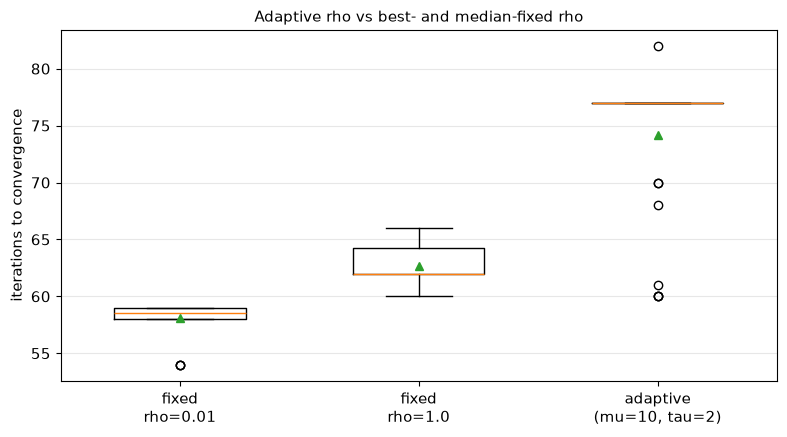

In [8]:
graph = CommunicationGraph.cycle(4)
rho_best = best_rho  # empirical optimum from the rho sweep above

adaptive_iters = np.array([run_trial(graph, seed=s, adaptive_rho=True).iterations
                           for s in range(SEEDS)])
best_fixed_iters = np.array([run_trial(graph, seed=s, rho=rho_best).iterations
                             for s in range(SEEDS)])
median_fixed_iters = np.array([run_trial(graph, seed=s, rho=1.0).iterations
                               for s in range(SEEDS)])

def _summary(name, arr):
    print(f"{name:14s}: median={np.median(arr):5.1f}, mean={arr.mean():5.1f}, "
          f"min={arr.min():4d}, max={arr.max():4d}")

_summary("adaptive", adaptive_iters)
_summary("best fixed", best_fixed_iters)
_summary("median fixed", median_fixed_iters)
print(f"adaptive / best-fixed   = {np.median(adaptive_iters) / np.median(best_fixed_iters):.2f}")
print(f"adaptive / median-fixed = {np.median(adaptive_iters) / np.median(median_fixed_iters):.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(
    [best_fixed_iters, median_fixed_iters, adaptive_iters],
    tick_labels=[f"fixed\nrho={rho_best:.3g}", "fixed\nrho=1.0", "adaptive\n(mu=10, tau=2)"],
    widths=0.55,
    showmeans=True,
)
ax.set_ylabel("iterations to convergence")
ax.set_title("Adaptive rho vs best- and median-fixed rho")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Figure export

Write `media/convergence_curves.png` at README resolution.

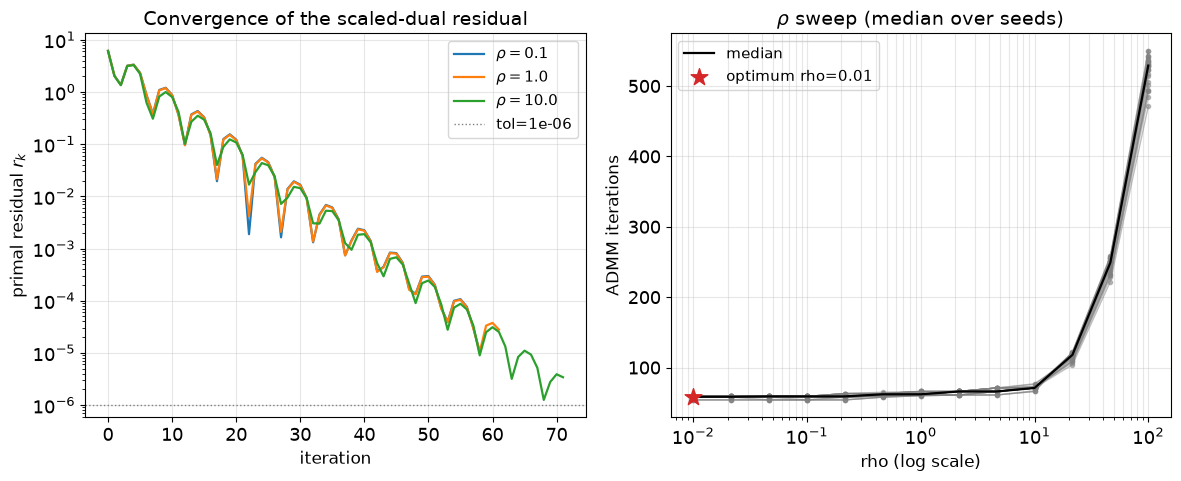

wrote /home/eiman/Documents/ephd/ros-ws/src/distributed-mpc-admm/media/convergence_curves.png


tol_cycle_2.npz: mean_iters=28.9


tol_cycle_4.npz: mean_iters=205.6


tol_cycle_6.npz: mean_iters=465.4


tol_complete_2.npz: mean_iters=36.2


...

tol_star_2.npz: mean_iters=28.8


tol_star_4.npz: mean_iters=206.5


tol_star_6.npz: mean_iters=539.2


warmstart_warm.npz: mean_iters=97.8


warmstart_cold.npz: mean_iters=97.8


In [9]:
_NB_CI = os.environ.get("NB_CI") == "1"

# --- README figure ----------------------------------------------------------
plotting.apply_style("readme")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
graph = CommunicationGraph.cycle(4)
for rho in (0.1, 1.0, 10.0):
    r = run_trial(graph, seed=0, rho=rho)
    ax1.semilogy(
        np.asarray(r.history.primal_residual),
        linewidth=1.6,
        label=rf"$\rho={rho}$",
    )
ax1.axhline(TOL, color="grey", linestyle=":", linewidth=1.0, label=rf"tol={TOL:g}")
ax1.set_xlabel("iteration")
ax1.set_ylabel(r"primal residual $r_k$")
ax1.set_title("Convergence of the scaled-dual residual")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="best", fontsize="small")

plotting.plot_rho_sweep(rho_values, rho_iters, ax=ax2)
ax2.set_title(r"$\rho$ sweep (median over seeds)")
plt.tight_layout()
fig.savefig(repo_root / "media" / "convergence_curves.png", transparent=True, dpi=150)
plt.show()
print("wrote", repo_root / "media" / "convergence_curves.png")

# --- data for analysis/iterations_to_consensus.ipynb -------------------------
# Closed-loop rendezvous runs whose SimulationLog is cached so the analysis
# notebook can regenerate its figures in seconds without re-simulating.
data_dir = repo_root / "analysis" / "data"
data_dir.mkdir(parents=True, exist_ok=True)


def _closed_loop(graph: CommunicationGraph, tol: float, *, n_steps: int, warm_start: bool):
    formation = FormationSpec.rendezvous(graph.n_agents, graph)
    x0 = np.random.default_rng(0).normal(size=(graph.n_agents, _model.n_states))
    x0[:, _model.dim :] *= 0.5
    # Pure consensus: no leader reference, so the tracking weights must be zero.
    weights = AgentCostWeights(q_position=0.0, p_terminal=0.0)
    admm_opts = ADMMOptions(
        rho=1.0,
        max_iterations=MAX_ITER,
        eps_abs=tol,
        eps_rel=tol,
        warm_start=warm_start,
    )
    mpc_opts = MPCOptions(horizon=10, n_steps=n_steps)
    mpc = DistributedMPC(
        _model, graph, formation, _limits, weights, admm_opts, mpc_opts
    )
    return mpc.run(x0)


_topo_factories = [
    ("cycle", CommunicationGraph.cycle(4)),
    ("complete", CommunicationGraph.complete(4)),
    ("path", CommunicationGraph.path(4)),
    ("star", CommunicationGraph.star(4)),
]
if _NB_CI:
    _topo_factories = _topo_factories[:2]
_tols = [("2", 1e-2), ("4", 1e-4), ("6", 1e-6)]
if _NB_CI:
    _tols = _tols[:2]

for name, g in _topo_factories:
    for exp, tol in _tols:
        n_steps = 2 if _NB_CI else 10
        log = _closed_loop(g, tol, n_steps=n_steps, warm_start=True)
        path = data_dir / f"tol_{name}_{exp}.npz"
        log.save(path)
        print(f"{path.name}: mean_iters={log.summary()['mean_admm_iterations']:.1f}")

for mode, warm in (("warm", True), ("cold", False)):
    n_steps = 3 if _NB_CI else 25
    log = _closed_loop(CommunicationGraph.cycle(4), 1e-4, n_steps=n_steps, warm_start=warm)
    path = data_dir / f"warmstart_{mode}.npz"
    log.save(path)
    print(f"{path.name}: mean_iters={log.summary()['mean_admm_iterations']:.1f}")


## Takeaway

Iteration count is governed by algebraic connectivity and rho, and is nearly independent of the horizon; wall time is governed by the local QP size.